# Visualizing the Two-Stage Model

This notebook visualizes the two-stage modeling approach, where location is the primary predictor and other features act as adjustments.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

## 1. Load and Prepare Data

In [2]:
file_path = 'california_housing.csv'
housing_df = pd.read_csv(file_path)

# Preprocessing
housing_df['bed_to_room_ratio'] = housing_df['AveBedrms'] / housing_df['AveRooms']
housing_df.replace([np.inf, -np.inf], np.nan, inplace=True)
housing_df.dropna(inplace=True)
housing_df = housing_df[(housing_df['AveOccup'] < 10) & (housing_df['AveRooms'] < 40)]

# Feature Selection
location_features = ['Latitude', 'Longitude']
adjustment_features = ['MedInc', 'AveOccup', 'bed_to_room_ratio']
X = housing_df[location_features + adjustment_features]
y = housing_df['MedHouseVal']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 2. Stage 1: Location Model Visualization

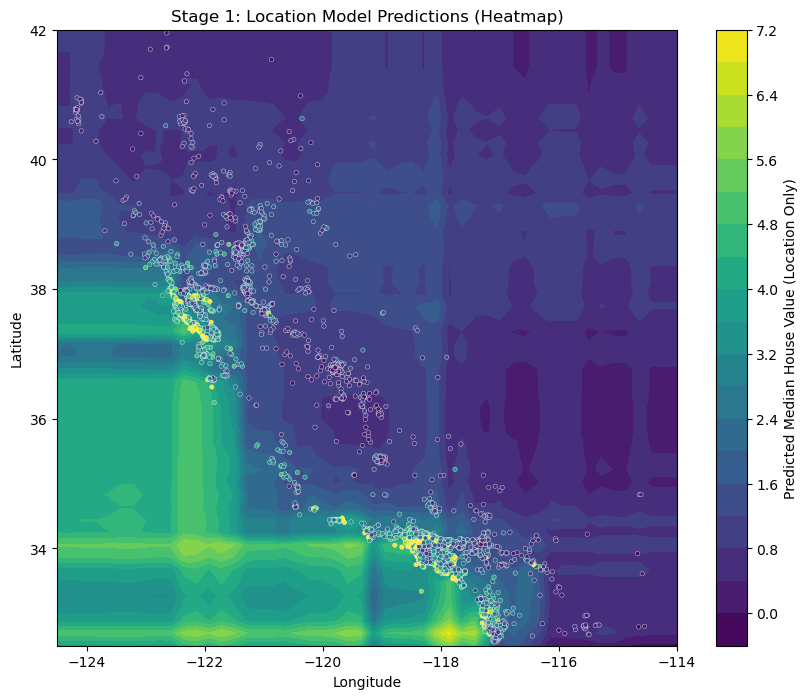

In [3]:
# Train Stage 1 Model
location_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
location_model.fit(X_train[location_features], y_train)

# Create a grid for visualization
grid_lon, grid_lat = np.meshgrid(np.linspace(-124.5, -114, 50), np.linspace(32.5, 42, 50))
grid_df = pd.DataFrame({'Longitude': grid_lon.ravel(), 'Latitude': grid_lat.ravel()})
grid_predictions = location_model.predict(grid_df[location_features])

# Plotting the location-based predictions (the "cured screen")
plt.figure(figsize=(10, 8))
contour = plt.tricontourf(grid_df['Longitude'], grid_df['Latitude'], grid_predictions, levels=20, cmap='viridis')
plt.colorbar(label='Predicted Median House Value (Location Only)')
sns.scatterplot(x='Longitude', y='Latitude', data=X_test, hue=y_test, palette='viridis', s=10, legend=None)
plt.title('Stage 1: Location Model Predictions (Heatmap)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

## 3. Stage 2: Residuals Visualization

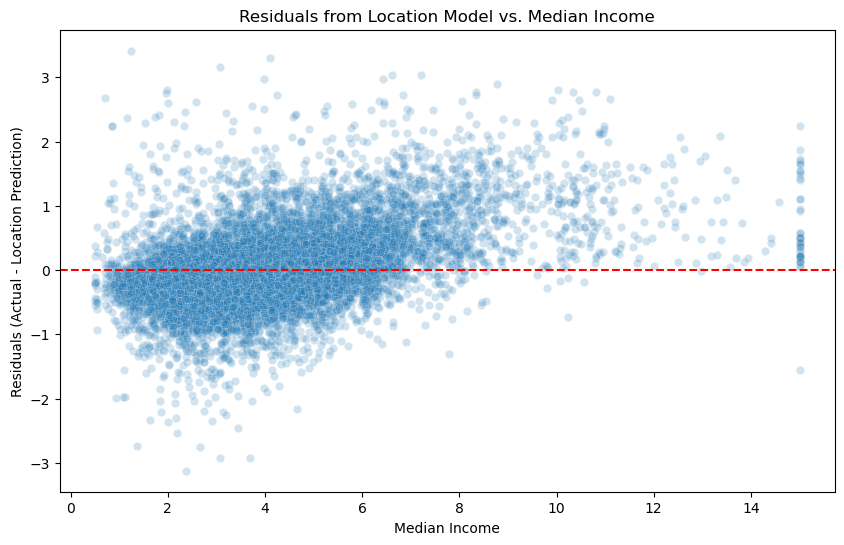

In [4]:
# Calculate residuals
location_predictions_train = location_model.predict(X_train[location_features])
residuals_train = y_train - location_predictions_train

# Train Stage 2 Model
residual_model = Ridge(alpha=1.0)
residual_model.fit(X_train[adjustment_features], residuals_train)

# Plot residuals vs. one of the adjustment features (MedInc)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_train['MedInc'], y=residuals_train, alpha=0.2)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals from Location Model vs. Median Income')
plt.xlabel('Median Income')
plt.ylabel('Residuals (Actual - Location Prediction)')
plt.show()

## 4. Final vs. Actual Predictions

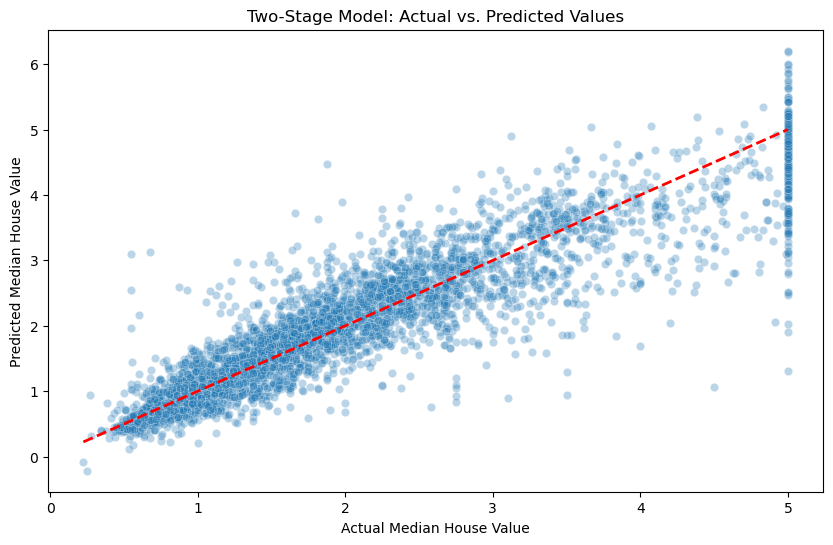

In [5]:
# Make final predictions
location_predictions_test = location_model.predict(X_test[location_features])
residual_predictions_test = residual_model.predict(X_test[adjustment_features])
final_predictions = location_predictions_test + residual_predictions_test

# Plot final predictions vs. actual values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=final_predictions, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title('Two-Stage Model: Actual vs. Predicted Values')
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.show()